# **C. Introducción a QAOA mediante el problema MaxCut: de QUBO a Hamiltonianos de Ising**

##*Universidad Nacional Autónoma de México*

#Laboratorio Avanzado de Procesamiento de Imágenes

#Autor: **Sebastián González Juárez**

Temas Selectos de Ingenieria III - **Introducción a la computación cuántica**.

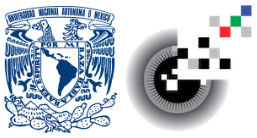

---

# **1. Problema: MaxCut**

En esta clase utilizaremos el problema MaxCut como ejemplo introductorio para aprender la ruta completa de optimización cuántica:

$$Problema$$
$$↓$$
$$QUBO$$
$$↓$$
$$Ising$$
$$↓$$
$$QAOA$$
$$↓$$
$$Solución$$

El objetivo principal será entender cómo un problema clásico puede transformarse en una representación matemática compatible con algoritmos cuánticos variacionales.

##**1.1. Idea general**

El problema **MaxCut** (Maximum Cut) consiste en **dividir los nodos** de una red en dos grupos de manera que se maximice el número de conexiones entre grupos distintos.

Aunque en este notebook utilizaremos un grafo pequeño como ejemplo introductorio, el problema MaxCut aparece de forma natural en múltiples áreas de optimización combinatoria.

Algunas aplicaciones incluyen:
- **Diseño de circuitos electrónicos:** dividir componentes y conexiones en módulos optimizando el diseño físico del sistema.
- **Redes de comunicación:** segmentar redes, distribuir carga o analizar conectividad entre dispositivos y servidores.
- **Organización y asignación de grupos:** separar elementos altamente relacionados o generar particiones equilibradas.
- **Logística y transporte:** optimizar flujos, separar regiones operativas o reducir congestión en redes complejas.

Muchos de estos problemas comparten una estructura común basada en variables binarias y funciones de optimización, lo que permite formularlos posteriormente como problemas QUBO y resolverlos mediante algoritmos variacionales como QAOA.

##**1.2. Grafo del problema**

Usaremos el siguiente grafo de 4 nodos.
- Nodos: **{0,1,2,3}**
- Aristas: **{(0,1),(0,2),(1,2),(1,3),(2,3)}**

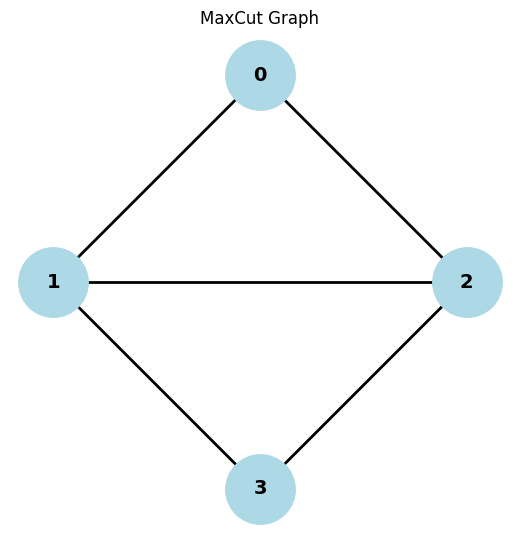

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo vacío
G = nx.Graph()

# Nodos
G.add_nodes_from([0, 1, 2, 3])

# Aristas
edges = [(0, 1),(0, 2),(1, 2),(1, 3),(2, 3)]

G.add_edges_from(edges)

# Posiciones
pos = {0: (0, 1),1: (-1, 0),2: (1, 0),3: (0, -1)}

# Dibujar grafo
plt.figure(figsize=(5,5))
nx.draw(G,pos,with_labels=True,node_color="lightblue",node_size=2500,font_size=14,font_weight="bold",width=2)
plt.title("MaxCut Graph")
plt.show()

## **1.3 División del grafo y definición de cortes**

Consideremos la siguiente división:
- Grupo A: **{0,3}**
- Grupo B: **{1,2}**

Para representar matemáticamente los grupos utilizaremos variables binarias:
- $x_i = 0$  → nodo i pertenece al grupo A
- $x_i = 1$  → nodo i pertenece al grupo B

| Nodo | Grupo | Variable  |
| ---- | ----- | --------- |
| 0    | A     | $x_0 = 0$ |
| 1    | B     | $x_1 = 1$ |
| 2    | B     | $x_2 = 1$ |
| 3    | A     | $x_3 = 0$ |

o equivalentemente: $x=[0,1,1,0]$

Solución binaria: [0, 1, 1, 0]
Aristas cortadas: [(0, 1), (0, 2), (1, 3), (2, 3)]
Número total de cortes: 4


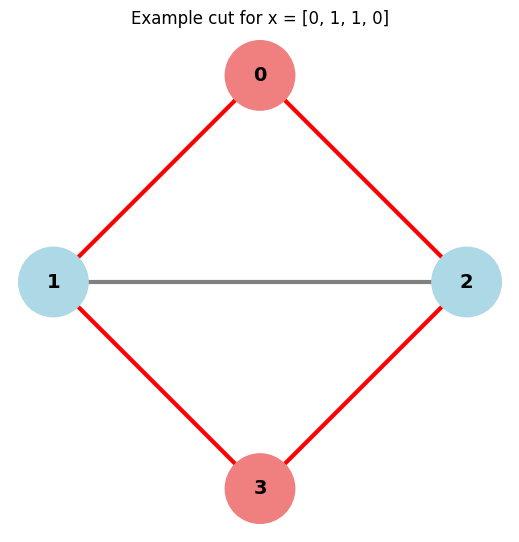

In [ ]:
# División propuesta:
solution = [0, 1, 1, 0]

# Calcular cuántas aristas son cortadas
cut_edges = []

for i, j in edges:
    if solution[i] != solution[j]:
        cut_edges.append((i, j))

print("Solución binaria:", solution)
print("Aristas cortadas:", cut_edges)
print("Número total de cortes:", len(cut_edges))

# Colores según el grupo
node_colors = ["lightcoral" if solution[i] == 0 else "lightblue" for i in G.nodes()]

# Colores de aristas: rojo si hay corte, gris si no
edge_colors = ["red" if solution[i] != solution[j] else "gray" for i, j in G.edges()]
plt.figure(figsize=(5,5))
nx.draw(G,pos,with_labels=True,node_color=node_colors,edge_color=edge_colors,node_size=2500,font_size=14,font_weight="bold",width=3)
plt.title("Example cut for x = [0, 1, 1, 0]")
plt.show()

| Arista | Grupos | ¿Hay corte? |
| ------ | ------ | ----------- |
|0--1| A-B    | Sí           |
|0--2| A-B    | Sí           |
|1--2| B-B    | No           |
|1--3| B-A    | Sí           |
|2--3| B-A    | No           |


---

# **2. Construcción del QUBO**

Ahora el objetivo es convertir la idea definida con MaxCut en una función matemática que pueda evaluarse para cualquier asignación binaria.

## **2.1. ¿Qué es un QUBO?**

QUBO significa:

    Quadratic Unconstrained Binary Optimization   →  Optimización Binaria Cuadrática Sin Restricciones

Un problema QUBO consiste en optimizar una función construida con variables binarias:
$$x_i \in \{0,1\}$$

En MaxCut:
- $x_i = 0$ indica que el nodo $i$ pertenece al grupo A,
- $x_i = 1$ indica que el nodo $i$ pertenece al grupo B.

La forma general de un QUBO es:
$$C(x)=\sum_i a_i x_i+\sum_{i<j} b_{ij}x_ix_j$$
donde:
- $a_i x_i$ representa contribuciones individuales,
- $b_{ij}x_ix_j$ representa interacciones entre variables binarias.

En general, QUBO medirá cuántas aristas son cortadas por una división dada del grafo y el objetivo consiste en encontrar la solución que maximiza o minimiza dicha función.



## **2.2. Construcción de la función QUBO para MaxCut**

Ahora construiremos la función matemática que permitirá evaluar cuántas aristas son cortadas por una determinada división del grafo.

$$i ----- j$$

Queremos una función que:

- valga 1 si los nodos están en grupos distintos,
- valga 0 si pertenecen al mismo grupo.

La expresión que cumple esta condición es:
$$x_i(1-x_j)+x_j(1-x_i)$$

| $x_i$ | $x_j$ | Sustitución | Resultado | ¿Hay corte? |
|---|---|---|---|---|
| 0 | 0 | 0(1-0)+0(1-0) | 0+0=0 | No |
| 0 | 1 | 0(1-1)+1(1-0) | 0+1=1 | Sí |
| 1 | 0 | 1(1-0)+0(1-1) | 1+0=1 | Sí |
| 1 | 1 | 1(1-1)+1(1-1) | 0+0=0 | No |

Por tanto, la expresión efectivamente identifica cuándo una arista es cortada.



**Expandimos la expresión:**

$$x_i(1-x_j)+x_j(1-x_i)$$

Distribuyendo términos:

$$x_i-x_ix_j+x_j-x_ix_j$$

Agrupando:

$$x_i+x_j-2x_ix_j$$

Esta forma es importante porque ya tiene la estructura típica de un problema QUBO:

- términos lineales: $x_i, x_j$

- término cuadrático:$x_ix_j$

Nuestro grafo contiene las aristas: E={${(0,1),(0,2),(1,2),(1,3),(2,3)}$}

Por tanto, la función QUBO completa es:

$$C(x)=(x_0+x_1-2x_0x_1)+(x_0+x_2-2x_0x_2)+(x_1+x_2-2x_1x_2)+(x_1+x_3-2x_1x_3)+(x_2+x_3-2x_2x_3)$$

Esta expresión ya tiene la forma típica de un problema QUBO:

$$C(x)=\sum_i a_i x_i+\sum_{i<j} b_{ij}x_ix_j$$

donde $a_i=a_j=1$ y $b_{ij}=-2$:


$$C(x)=\sum_{(i,j)\in E}(x_i+x_j-2x_ix_j)$$

Esta función $C(x)$ asigna un valor a cada posible cadena binaria:

$$x=[x_0,x_1,x_2,x_3]$$

y dicho valor corresponde al número total de aristas cortadas por esa división del grafo.

**Ejemplo: evaluación del QUBO**

Evaluemos la función QUBO para la división:

$$x=[0,1,1,0]$$

Recordemos que:

| Nodo | Variable | Grupo |
|---|---|---|
| 0 | $x_0=0$ | A |
| 1 | $x_1=1$ | B |
| 2 | $x_2=1$ | B |
| 3 | $x_3=0$ | A |

Sustituyendo en la función QUBO obtenida para MaxCut:

$$C(x)=(0+1-2(0)(1))+(0+1-2(0)(1))+(1+1-2(1)(1))+(1+0-2(1)(0))+(1+0-2(1)(0))=1+1+0+1+1=4$$

lo que indica que esta división produce un total de 4 aristas cortadas.

## **2.3. Construcción del QUBO con Qiskit**


Utilizaremos Qiskit para generar automáticamente esta formulación a partir del grafo definido anteriormente.


In [ ]:
!pip install qiskit qiskit-aer qiskit-optimization qiskit-algorithms networkx matplotlib numpy scipy --quiet


In [ ]:
import qiskit
import qiskit_aer
import qiskit_optimization
import qiskit_algorithms

print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Optimization:", qiskit_optimization.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)

Qiskit: 2.4.1
Qiskit Aer: 0.17.2
Qiskit Optimization: 0.7.0
Qiskit Algorithms: 0.4.0


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from qiskit_optimization.applications import Maxcut

Primero definimos los nodos y las conexiones del grafo:

In [ ]:
n_nodes = 4

edges = [(0, 1),(0, 2),(1, 2),(1, 3),(2, 3)]

**Qiskit Maxcut** recibe una matriz de pesos.

In [ ]:
w = np.zeros((n_nodes, n_nodes), dtype=int)

for i, j in edges:
    w[i, j] = 1
    w[j, i] = 1

print(w)

[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 1]
 [0 1 1 0]]


Esta matriz indica si dos nodos están conectados:
- $w[i,j] = 1$ → existe una arista entre $i$ y $j$
- $w[i,j] = 0$ → no existe una arista entre $i$ y $j$

In [ ]:
maxcut = Maxcut(w)

qp = maxcut.to_quadratic_program()

print(qp)

maximize -2*x_0*x_1 - 2*x_0*x_2 - 2*x_1*x_2 - 2*x_1*x_3 - 2*x_2*x_3 + 2*x_0 + 3*x_1 + 3*x_2 + 2*x_3 (4 variables, 0 constraints, 'Max-cut')


Verificando con l oqeu teníamos de la sección anterior:

$$C(x)=(x_0+x_1-2x_0x_1)+(x_0+x_2-2x_0x_2)+(x_1+x_2-2x_1x_2)+(x_1+x_3-2x_1x_3)+(x_2+x_3-2x_2x_3)$$


 Qiskit genera automáticamente el problema de optimización binaria asociado a MaxCut.

**Evaluación Clásica como referencia**

Antes de pasar a Ising y QAOA, podemos resolver el problema de forma clásica por fuerza bruta.
Como solo hay 4 nodos, existen:

$$2^4=16$$

posibles soluciones.

In [ ]:
from itertools import product

# Mejor solución
best_x = None
best_value = -float("inf")

# Probar todas las cadenas binarias
for k, x in enumerate(product([0, 1], repeat=n_nodes)):

    # Convertir a diccionario
    x_dict = {f"x_{i}": x[i] for i in range(n_nodes)}

    # Evaluar QUBO
    value = qp.objective.evaluate(x_dict)

    # Imprimir iteración
    print(f"Iter {k:02d} | x = {x} | value = {value}")

    # Actualizar máximo
    if value > best_value:
        best_value = value
        best_x = x

print("\nBest solution:", best_x)
print("MaxCut value:", best_value)

Iter 00 | x = (0, 0, 0, 0) | value = 0.0
Iter 01 | x = (0, 0, 0, 1) | value = 2.0
Iter 02 | x = (0, 0, 1, 0) | value = 3.0
Iter 03 | x = (0, 0, 1, 1) | value = 3.0
Iter 04 | x = (0, 1, 0, 0) | value = 3.0
Iter 05 | x = (0, 1, 0, 1) | value = 3.0
Iter 06 | x = (0, 1, 1, 0) | value = 4.0
Iter 07 | x = (0, 1, 1, 1) | value = 2.0
Iter 08 | x = (1, 0, 0, 0) | value = 2.0
Iter 09 | x = (1, 0, 0, 1) | value = 4.0
Iter 10 | x = (1, 0, 1, 0) | value = 3.0
Iter 11 | x = (1, 0, 1, 1) | value = 3.0
Iter 12 | x = (1, 1, 0, 0) | value = 3.0
Iter 13 | x = (1, 1, 0, 1) | value = 3.0
Iter 14 | x = (1, 1, 1, 0) | value = 2.0
Iter 15 | x = (1, 1, 1, 1) | value = 0.0

Best solution: (0, 1, 1, 0)
MaxCut value: 4.0


---

# **3. De QUBO a Hamiltonianos de Ising**


Para poder implementar QAOA, el problema debe expresarse en términos de un Hamiltoniano de Ising.

## **3.1. ¿Qué es un Hamiltoniano de Ising?**

El modelo de Ising proviene originalmente de física estadística y se utiliza para describir sistemas de spins discretos con interacciones locales. Cada spin puede tomar dos estados posibles, y la energía total del sistema depende de las interacciones entre spins vecinos.


En la figura mostrada, las conexiones favorecen spins opuestos, por lo que configuraciones con mayor número de interacciones satisfechas presentan menor energía.

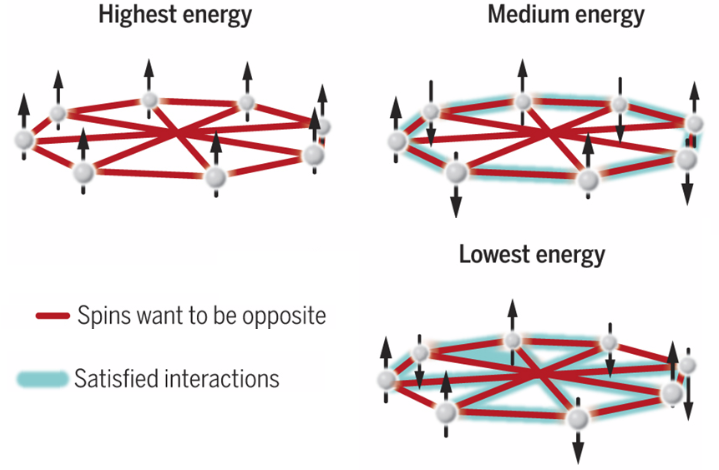

En este modelo, cada variable puede tomar únicamente dos valores:

$$z_i \in \{-1,+1\}$$

Y la relación es:

| Modelo | Variable | Valores posibles | Interpretación |
|---|---|---|---|
| QUBO | $x_i$ | ${0,1}$ | variable binaria |
| Ising | $z_i$ | ${-1,+1}$ | spin abajo / spin arriba |

La forma general de un Hamiltoniano de Ising es:

$$H=\sum_i h_i z_i+\sum_{i<j}J_{ij}z_i z_j$$

El término $J_{ij}z_i z_j$ modela la interacción entre spins vecinos, donde $J_{ij}$ controla la intensidad y el tipo de interacción entre los spins $i$ y $j$.

Por otro lado, el término $h_i z_i$ representa un posible campo externo aplicado localmente sobre el spin $i$.

**Interpretación de las interacciones**

El término: $$z_i z_j$$ depende de si los spins son iguales o distintos.

| $z_i$ | $z_j$ | $z_i z_j$ |
|---|---|---|
| $+1$ | $+1$ | $+1$ |
| $+1$ | $-1$ | $-1$ |
| $-1$ | $+1$ | $-1$ |
| $-1$ | $-1$ | $+1$ |

Por tanto:

- spins iguales $+1$
- spins opuestos $-1$

Esta propiedad conecta naturalmente el modelo de Ising con MaxCut, ya que el problema busca separar nodos conectados en grupos distintos.

## **3.2. Conversión de variables binarias a spins**

Para transformar el QUBO en un Hamiltoniano de Ising, convertimos las variables binarias:

$$
x_i \in \{0,1\}
$$

en variables de spin:

$$
z_i \in \{-1,+1\}
$$

La transformación estándar es:

$$
x_i=\frac{1-z_i}{2}
$$

Por tanto, para dos nodos conectados $i$ y $j$:

$$
x_i=\frac{1-z_i}{2}, \qquad x_j=\frac{1-z_j}{2}
$$

| $z_i$ | Sustitución | $x_i$ |
|---|---|---|
| $+1$ | $\frac{1-(+1)}{2}$ | $0$ |
| $-1$ | $\frac{1-(-1)}{2}$ | $1$ |


Recordemos que el término QUBO de una arista es:

$$
x_i+x_j-2x_ix_j
$$

Sustituyendo:

$$
x_i=\frac{1-z_i}{2}, \qquad x_j=\frac{1-z_j}{2}
$$

obtenemos:

$$
x_i+x_j-2x_ix_j
=
\frac{1-z_i}{2}
+
\frac{1-z_j}{2}
-
2\left(\frac{1-z_i}{2}\right)\left(\frac{1-z_j}{2}\right)
$$

Desarrollamos el producto:

$$
\left(\frac{1-z_i}{2}\right)\left(\frac{1-z_j}{2}\right)
=
\frac{(1-z_i)(1-z_j)}{4}
$$

$$
=
\frac{1-z_i-z_j+z_iz_j}{4}
$$

Entonces:

$$
x_i+x_j-2x_ix_j
=
\frac{1-z_i}{2}
+
\frac{1-z_j}{2}
-
2\left(\frac{1-z_i-z_j+z_iz_j}{4}\right)
$$

$$
=
\frac{1-z_i}{2}
+
\frac{1-z_j}{2}
-
\frac{1-z_i-z_j+z_iz_j}{2}
$$

Unificando en un solo denominador:

$$
=
\frac{1-z_i+1-z_j-(1-z_i-z_j+z_iz_j)}{2}
$$

$$
=
\frac{2-z_i-z_j-1+z_i+z_j-z_iz_j}{2}
$$

$$
=
\frac{1-z_iz_j}{2}
$$

Por tanto, el término QUBO de una arista se transforma como:

$$
x_i+x_j-2x_ix_j
=
\frac{1-z_iz_j}{2}
$$

Para todo el grafo, la función QUBO:

$$
C(x)=\sum_{(i,j)\in E}(x_i+x_j-2x_ix_j)
$$

se transforma en:

$$
C(z)=\sum_{(i,j)\in E}\frac{1-z_iz_j}{2}
$$

Esta expresión ya está escrita en términos de spins y corresponde a la forma de Ising asociada al problema MaxCut.

## **3.3. Hamiltoniano de Ising para MaxCut**

La función de Ising obtenida para MaxCut fue:

$$
C(z)=\sum_{(i,j)\in E}\frac{1-z_i z_j}{2}
$$

Sustituyendo las aristas de nuestro grafo: (0,1), (0,2), (1,2), (1,3) (2,3).

obtenemos:

$$
\begin{aligned}
H_C=&
\frac{1-z_0z_1}{2}
+
\frac{1-z_0z_2}{2}
+
\frac{1-z_1z_2}{2}\\
&+
\frac{1-z_1z_3}{2}
+
\frac{1-z_2z_3}{2}
\end{aligned}
$$

Aunque MaxCut se plantea como un problema de maximización de cortes, el modelo de Ising y QAOA trabajan naturalmente minimizando energía. De esta manera:

    más cortes ↔ menor energía


Para implementar el problema en computación cuántica, los spins son reemplazados por operadores de Pauli-Z:

$$
z_i \rightarrow Z_i
$$

y:

$$
z_i z_j \rightarrow Z_i Z_j
$$

Por tanto, el Hamiltoniano cuántico asociado al problema queda:

$$
H_C=\sum_{(i,j)\in E}\frac{1-Z_i Z_j}{2}
$$

Esta expresión corresponde al Hamiltoniano costo utilizado posteriormente por QAOA.

## **3.4. Construcción automática del Hamiltoniano de Ising con Qiskit**

Ahora convertimos automáticamente el problema QUBO al Hamiltoniano de Ising correspondiente utilizando Qiskit:

In [ ]:
# Convertir el QUBO a Hamiltoniano de Ising
ising_hamiltonian, offset = qp.to_ising()

# Mostrar resultados
print("Ising Hamiltonian:")
print(ising_hamiltonian)

print("\nOffset:")
print(offset)

Ising Hamiltonian:
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])

Offset:
-2.5


El Hamiltoniano contiene cinco términos de tipo:

$$
Z_i Z_j
$$

correspondientes a las cinco aristas del grafo:

| Arista | Término Pauli |
|---|---|
| (0,1) | `IIZZ` |
| (0,2) | `IZIZ` |
| (1,2) | `IZZI` |
| (1,3) | `ZIZI` |
| (2,3) | `ZZII` |

Cada término representa una interacción entre dos qubits asociados a nodos conectados del grafo.

Los coeficientes:

$$
0.5
$$

provienen de la formulación:

$$
\frac{1-Z_i Z_j}{2}
$$

obtenida anteriormente para cada arista del problema MaxCut.

Finalmente, el valor:

$$
\text{offset}=-2.5
$$

corresponde a un término constante generado durante la conversión QUBO → Ising. Este desplazamiento no modifica la solución óptima del problema, ya que únicamente desplaza globalmente la energía del sistema.

---

# **4. Quantum Approximate Optimization Algorithm (QAOA)**

Hasta ahora hemos obteniendo el Hamiltoniano:
$$
H_C=\sum_{(i,j)\in E}\frac{1-Z_i Z_j}{2}
$$

Ahora utilizaremos este Hamiltoniano dentro del algoritmo QAOA.

## **4.1. Fundamentos de QAOA**

QAOA es un algoritmo variacional híbrido diseñado para aproximar soluciones de problemas de optimización combinatoria.

La idea principal consiste en preparar un estado cuántico cuyos estados de mayor probabilidad correspondan a configuraciones de baja energía del Hamiltoniano costo.

El algoritmo utiliza dos Hamiltonianos:

- **Hamiltoniano costo**, codifica el problema de optimización:

$$
H_C
$$


- **Hamiltoniano mezclador**, permite explorar distintas configuraciones binarias:

$$
H_M=\sum_i X_i
$$


A partir de ellos se construyen dos operadores unitarios:

* **Hamiltoniano costo**:

$$
U_C(\gamma)=e^{-i\gamma H_C}
$$

* **Hamiltoniano mezclador**:

$$
U_M(\beta)=e^{-i\beta H_M}
$$

donde:

- $\gamma$ controla la evolución asociada al problema.
- $\beta\$ controla la mezcla entre estados.

QAOA comienza preparando todos los qubits en superposición uniforme:

$$
|+\rangle^{\otimes n}
$$

mediante compuertas Hadamard:

$$
H^{\otimes n}
$$

De esta forma, inicialmente todas las configuraciones binarias tienen la misma probabilidad.

El algoritmo aplica alternadamente:

$$
U_C(\gamma)
$$

y:

$$
U_M(\beta)
$$

durante \(p\) capas:

$$
|\psi(\gamma,\beta)\rangle=
U_M(\beta_p)U_C(\gamma_p)\cdots
U_M(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}
$$

Los parámetros:

$$
\gamma=(\gamma_1,\dots,\gamma_p)
$$

y:

$$
\beta=(\beta_1,\dots,\beta_p)
$$

son optimizados clásicamente para minimizar:

$$
\langle \psi(\gamma,\beta)|H_C|\psi(\gamma,\beta)\rangle
$$

## **4.2. Implementación del Hamiltoniano costo**

Cada término del Hamiltoniano costo:

$$
e^{-i\gamma Z_i Z_j}
$$

se implementa mediante el siguiente bloque de compuertas, **circuito de costo**:

```text
q_i ──■────────────■──
       │            │
q_j ───X──RZ(2γ)────X──
```

donde:

- las compuertas CNOT generan la interacción entre qubits,
- y:$RZ(2\gamma)$ introduce una fase controlada por el parámetro variacional $\gamma$.

Este bloque implementa la evolución asociada a una interacción:

$$
Z_i Z_j
$$

por lo que el Hamiltoniano costo completo se construye aplicando este patrón sobre todas las aristas del grafo.

## **4.3. Implementación del Hamiltoniano mezclador**

El operador mezclador:

$$
U_M(\beta)=e^{-i\beta H_M}
$$

se implementa aplicando rotaciones:

$$
RX(2\beta)
$$

sobre cada qubit.

**Circuito del mezclador**

```text
q_0 ──RX(2β)──
q_1 ──RX(2β)──
q_2 ──RX(2β)──
q_3 ──RX(2β)──
```

Estas rotaciones permiten explorar nuevas configuraciones del espacio de soluciones.

## **4.4 Circuito de una capa QAOA**

Una capa QAOA con profundidad:

$$
p=1
$$

se construye aplicando secuencialmente:

```text
Hadamards
↓
Hamiltoniano costo U_C(γ)
↓
Hamiltoniano mezclador U_M(β)
```

El circuito comienza preparando todos los qubits en superposición uniforme mediante compuertas Hadamard.

Posteriormente se aplican:

- los bloques asociados al Hamiltoniano costo para cada arista del grafo,
- y finalmente las rotaciones del mezclador.


**Estructura general**

```text
q_0 ──H────■────────────■────RX(2β)──
            │            │
q_1 ──H─────X──RZ(2γ)────X────RX(2β)──

q_2 ──H─────■────────────■────RX(2β)──
            │            │
q_3 ──H─────X──RZ(2γ)────X────RX(2β)──
```

En problemas reales, este patrón se aplica sobre todas las aristas del Hamiltoniano costo.

## **4.5 Interpretación física de QAOA**

El operador costo:

$$
U_C(\gamma)
$$

modifica las fases de los estados cuánticos según la energía asociada a cada configuración del problema.

Posteriormente, el operador mezclador:

$$
U_M(\beta)
$$

redistribuye amplitudes entre estados cuánticos, permitiendo explorar nuevas configuraciones del espacio de soluciones.

La combinación alternada de ambos operadores genera interferencia cuántica, aumentando progresivamente la probabilidad de medir estados asociados a soluciones de baja energía.

En el contexto de MaxCut:

```text
menor energía ↔ mayor número de cortes
```

por lo que QAOA busca incrementar la probabilidad de obtener particiones cercanas al corte máximo del grafo.

## 4.6 Optimización variacional

Los parámetros variacionales:

$$
\gamma
$$

y:

$$
\beta
$$

no se conocen previamente y deben optimizarse clásicamente.

QAOA utiliza un ciclo híbrido:

```text
Parámetros
↓
Circuito cuántico
↓
Mediciones
↓
Evaluación de energía
↓
Optimizador clásico
↓
Nuevos parámetros
```

En cada iteración, el circuito se ejecuta utilizando un conjunto de parámetros:

$$
(\gamma,\beta)
$$

y posteriormente se calcula el valor esperado:

$$
\langle H_C \rangle
$$

El optimizador clásico ajusta los parámetros buscando minimizar dicha energía y aproximar el estado fundamental del Hamiltoniano costo.

## **4.7. Implementación de QAOA con Qiskit**

Ahora implementaremos QAOA usando el Hamiltoniano de Ising obtenido previamente:

In [ ]:
# Sampler moderno compatible con QAOA
from qiskit.primitives import StatevectorSampler

# Algoritmo QAOA
from qiskit_algorithms.minimum_eigensolvers import QAOA

# Optimizador clásico
from qiskit_algorithms.optimizers import COBYLA

Configuración del sampler y optimizador:

In [ ]:
# Simulador
sampler = StatevectorSampler(seed=42)

# Optimizador clásico
optimizer = COBYLA(maxiter=100)

Construcción del algoritmo QAOA:

In [ ]:
# QAOA
qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=2
)

Ejecución:

In [ ]:
# Resolver el Hamiltoniano de Ising
result = qaoa.compute_minimum_eigenvalue(ising_hamiltonian)

# Mostrar resultado
print(result)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


{   'aux_operators_evaluated': None,
    'best_measurement': {   'bitstring': '1001',
                            'probability': 0.423828125,
                            'state': 9,
                            'value': np.complex128(-1.5+0j)},
    'cost_function_evals': 61,
    'eigenstate': {   '0000': 0.009765625,
                      '0001': 0.0068359375,
                      '0010': 0.0048828125,
                      '0011': 0.03125,
                      '0100': 0.005859375,
                      '0101': 0.015625,
                      '0110': 0.4228515625,
                      '0111': 0.005859375,
                      '1000': 0.0068359375,
                      '1001': 0.4111328125,
                      '1010': 0.02734375,
                      '1011': 0.001953125,
                      '1100': 0.0234375,
                      '1101': 0.005859375,
                      '1110': 0.0087890625,
                      '1111': 0.01171875},
    'eigenvalue': np.float64(-1.241210937

Resultado principal:

In [ ]:
# Energía mínima aproximada
print("Approximate minimum eigenvalue:", result.eigenvalue)

# Mejor medición encontrada, si está disponible
if hasattr(result, "best_measurement"):
    print("Best measurement:", result.best_measurement)

Approximate minimum eigenvalue: -1.2412109375
Best measurement: {'state': 9, 'bitstring': '1001', 'value': np.complex128(-1.5+0j), 'probability': 0.423828125}


## **4.8. Interpretación de resultados**

El algoritmo QAOA encontró el bitstring:

$$
1001
$$

correspondiente a la partición:

| Nodo | Grupo |
|---|---|
| 0 | 1 |
| 1 | 0 |
| 2 | 0 |
| 3 | 1 |

Esta configuración produce:

$$
4
$$

aristas cortadas, coincidiendo con la solución óptima obtenida previamente mediante búsqueda exhaustiva clásica.

El valor:

$$
\langle H_C \rangle
$$

reportado por QAOA corresponde a la energía esperada del estado cuántico final, mientras que `best_measurement` representa la mejor configuración binaria observada durante las mediciones.

Aunque este ejemplo utiliza un grafo pequeño, QAOA está diseñado para aproximar soluciones de problemas de optimización cuya búsqueda exhaustiva clásica crece exponencialmente con el número de variables.